# LeetCode #1419: Minimum Number of Frogs Croaking

https://leetcode.com/problems/minimum-number-of-frogs-croaking/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (simulate all frogs)** | $O(n \cdot k)$ | $O(k)$ |
| **Optimal: Greedy Counter ★** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (simulate all frogs)
Assign each character to an available frog in sequence; if none is ready, create a new frog. Track each frog's position in "croak". Requires $O(k)$ per step where $k$ is the number of active frogs.

### Optimal: Greedy Counter ★
Track a running count for each letter position in "croak". At each character, increment its counter and verify the prefix ordering invariant ($c \ge r \ge o \ge a \ge k$). The number of concurrent frogs at any moment equals $c - k$ (frogs that started but haven't finished). Return the maximum of this value.

**Why this is better than Brute Force:** No per-frog tracking is needed — five counters replace the entire frog list, giving $O(1)$ space and $O(n)$ time.

**Constraints:**
* $1 \le \text{croakOfFrogs.length} \le 10^5$
* `croakOfFrogs` contains only characters from `{'c','r','o','a','k'}`


## Solutions

### C#

In [ ]:
public int MinNumberOfFrogs(string croakOfFrogs) {
    int c=0, r=0, o=0, a=0, k=0, maxFrogs=0;
    foreach (char ch in croakOfFrogs) {
        // Increment the counter for each letter in "croak" order
        if      (ch=='c') c++;
        else if (ch=='r') r++;
        else if (ch=='o') o++;
        else if (ch=='a') a++;
        else              k++;
        // Invariant: each letter count must be >= the next letter's count
        if (c<r || r<o || o<a || a<k) return -1;
        // Concurrent frogs = those that started 'c' but not yet finished 'k'
        maxFrogs = Math.Max(maxFrogs, c - k);
    }
    // All frogs must have completed a full "croak"
    return c==r && r==o && o==a && a==k ? maxFrogs : -1;
}

### Python

In [ ]:
def min_number_of_frogs(croak_of_frogs: str) -> int:
    c = r = o = a = k = max_frogs = 0
    for ch in croak_of_frogs:
        # Increment the counter for each letter in "croak" order
        if   ch == 'c': c += 1
        elif ch == 'r': r += 1
        elif ch == 'o': o += 1
        elif ch == 'a': a += 1
        else:           k += 1
        # Invariant: each letter count must be >= the next letter's count
        if c < r or r < o or o < a or a < k:
            return -1
        # Concurrent frogs = those that started 'c' but not yet finished 'k'
        max_frogs = max(max_frogs, c - k)
    # All frogs must have completed a full "croak"
    return max_frogs if c == r == o == a == k else -1

### Go

In [ ]:
func minNumberOfFrogs(croakOfFrogs string) int {
    c, r, o, a, k, maxFrogs := 0, 0, 0, 0, 0, 0
    for _, ch := range croakOfFrogs {
        // Increment the counter for each letter in "croak" order
        switch ch {
        case 'c': c++
        case 'r': r++
        case 'o': o++
        case 'a': a++
        default:  k++
        }
        // Invariant: each letter count must be >= the next letter's count
        if c < r || r < o || o < a || a < k {
            return -1
        }
        // Concurrent frogs = those that started 'c' but not yet finished 'k'
        if c-k > maxFrogs { maxFrogs = c - k }
    }
    // All frogs must have completed a full "croak"
    if c == r && r == o && o == a && a == k { return maxFrogs }
    return -1
}

### Rust

In [ ]:
pub fn min_number_of_frogs(croak_of_frogs: String) -> i32 {
    let (mut c, mut r, mut o, mut a, mut k, mut max_frogs) = (0i32, 0, 0, 0, 0, 0);
    for ch in croak_of_frogs.chars() {
        // Increment the counter for each letter in "croak" order
        match ch {
            'c' => c += 1,
            'r' => r += 1,
            'o' => o += 1,
            'a' => a += 1,
            _   => k += 1,
        }
        // Invariant: each letter count must be >= the next letter's count
        if c < r || r < o || o < a || a < k { return -1; }
        // Concurrent frogs = those that started 'c' but not yet finished 'k'
        max_frogs = max_frogs.max(c - k);
    }
    // All frogs must have completed a full "croak"
    if c == r && r == o && o == a && a == k { max_frogs } else { -1 }
}

## Example Scenarios

**1. Common Case**
**Input:** `croakOfFrogs = "croakcroak"`
One frog completes "croak" then another starts. Counters: after first 'c', $c{-}k=1$ (1 frog active). After first 'k', $c{-}k=0$. Second croak repeats. Peak = 1. Return 1.

**2. Slightly Complex**
**Input:** `croakOfFrogs = "crcoakroak"`
Two frogs interleave: Frog A says 'c','r' then Frog B says 'c'. At that point $c{-}k=2$ (both active). They finish in order. Peak concurrent = 2. Return 2.

**3. Edge Case: Time Factor**
**Input:** `croakOfFrogs = "ccccroakroakroakroak"` (4 frogs)
All 4 frogs say 'c' before any finishes 'r'. After the 4th 'c', $c{-}k=4$. Each then completes sequentially. Scanning all $n$ characters is required to confirm completion. Return 4.

**4. Edge Case: Space Factor**
**Input:** `croakOfFrogs = "croakcroak..."` ($10^5$ chars, 1 frog)
Only 5 counters are ever needed regardless of input length — $O(1)$ space. Peak $c{-}k$ oscillates between 0 and 1. Return 1.

**5. Almost-Impossible but Plausible**
**Input:** `croakOfFrogs = "croak"` preceded by an extra 'r'
Input = `"rcroak"`. After 'r': $r=1 > c=0$ — invariant violated. Return -1 immediately without scanning further.


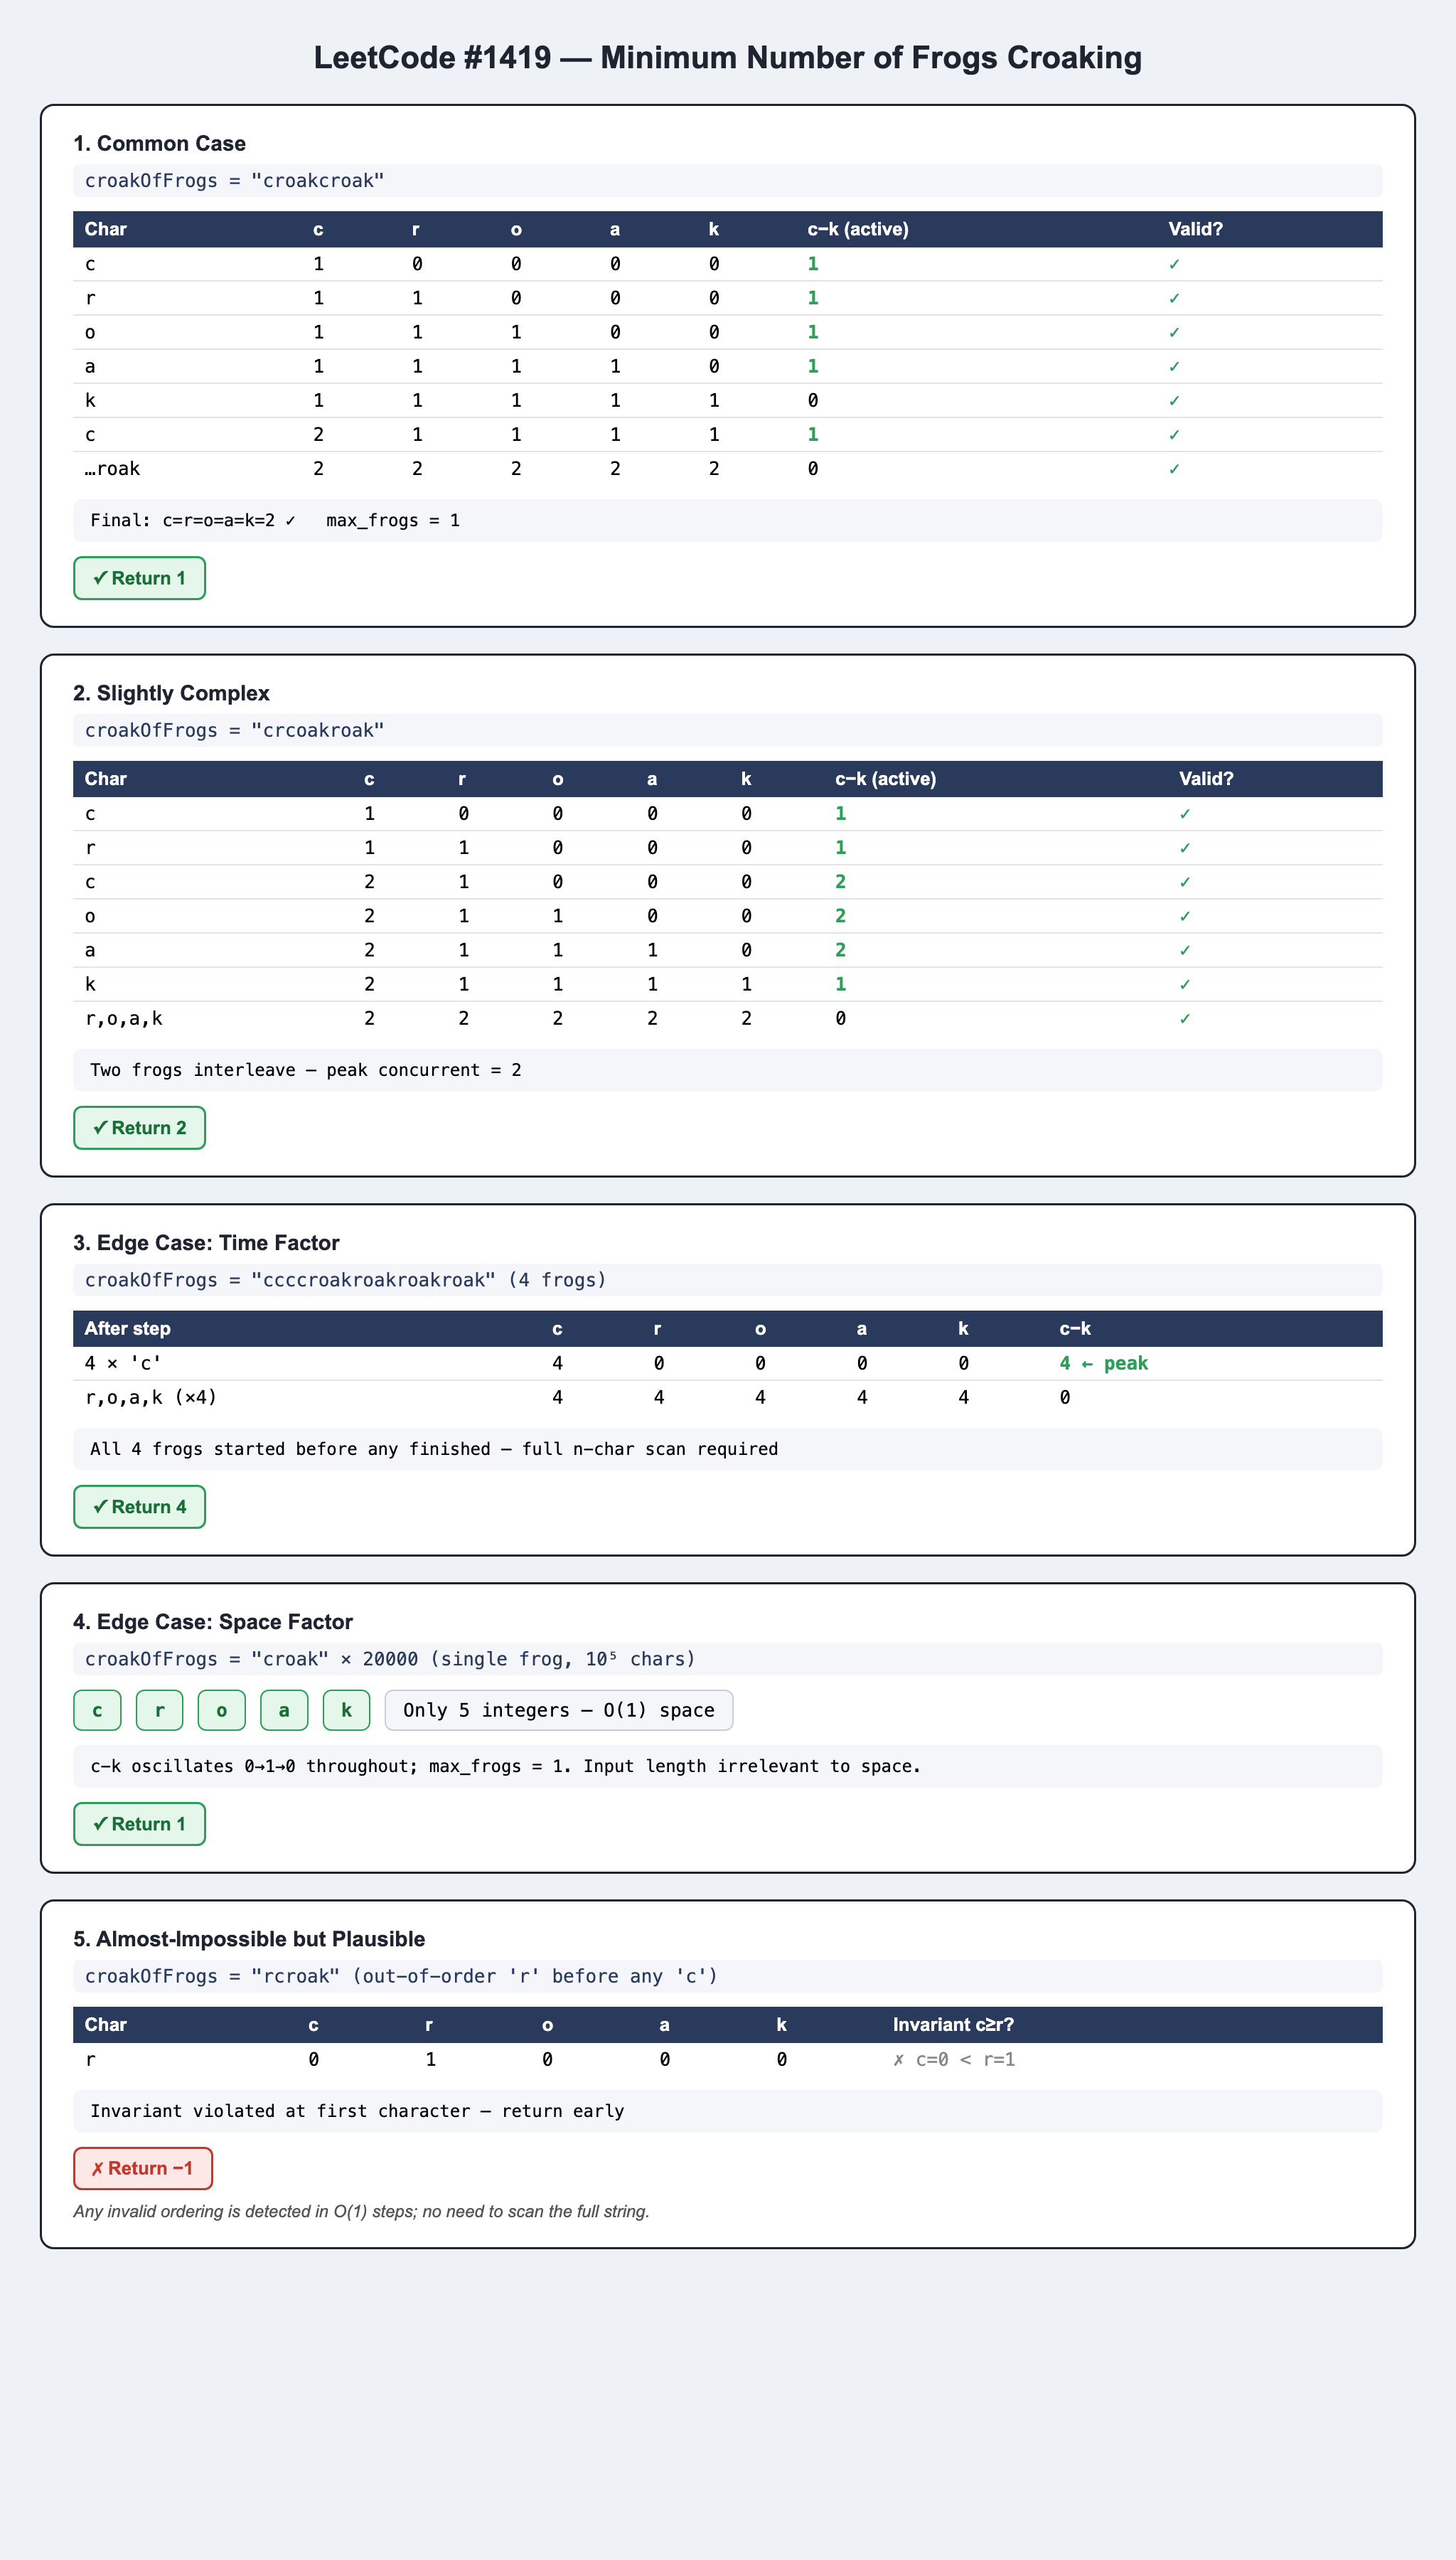